<a href="https://colab.research.google.com/github/JeanPablo-007/AnaliticaLab/blob/master/Py_Proyecto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Proyecto de clasificación

*   Jean Pablo Valencia Alejo
*   Alejandro Gutiérrez Aguillon
*   Kevin Alexis Gamez Morales






#### 0.-Setup

In [1]:
#Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import sklearn
from sklearn.model_selection import train_test_split
import seaborn as sns

### 1.- Cargar datos


In [2]:
Data = pd.read_csv('/content/battery_vs_gaming_dataset_medium.csv')

In [3]:
df = Data.copy()
df.head()

,Game_Name,Device_Type,Session_Time_Minutes,FPS,Battery_Start_%,Battery_End_%,Battery_Drop_%
0,Free Fire,iOS,86,90,53,40,13
1,Asphalt 9,Android,15,30,63,43,20
2,Free Fire,iOS,164,120,80,50,30
3,Call of Duty,Android,15,45,64,41,23
4,BGMI,iOS,174,30,75,56,19


### Creación de la variable `target`



In [4]:
conditions = [
    (df['Battery_Drop_%'] >= 30) & (df['Battery_Drop_%'] <= 40),
    (df['Battery_Drop_%'] >= 16) & (df['Battery_Drop_%'] <= 29),
    (df['Battery_Drop_%'] >= 0) & (df['Battery_Drop_%'] <= 15)
]

choices = [0, 1, 2]

df['target'] = np.select(conditions, choices, default=np.nan)

# Vamos a ver cómo quedó el DataFrame con la nueva columna 'target'
display(df.head())
display(df['target'].value_counts(dropna=False)) # Para verificar la distribución de las nuevas categorías

,Game_Name,Device_Type,Session_Time_Minutes,FPS,Battery_Start_%,Battery_End_%,Battery_Drop_%,target
0,Free Fire,iOS,86,90,53,40,13,2.0
1,Asphalt 9,Android,15,30,63,43,20,1.0
2,Free Fire,iOS,164,120,80,50,30,0.0
3,Call of Duty,Android,15,45,64,41,23,1.0
4,BGMI,iOS,174,30,75,56,19,1.0


,count
target,
1.0,408
0.0,308
2.0,284


In [5]:
d = {0:'Demandantes', 1:'Poco demandantes', 2:'No demandantes'}
df['target'] = df['target'].map(d)
df

,Game_Name,Device_Type,Session_Time_Minutes,FPS,Battery_Start_%,Battery_End_%,Battery_Drop_%,target
0,Free Fire,iOS,86,90,53,40,13,No demandantes
1,Asphalt 9,Android,15,30,63,43,20,Poco demandantes
2,Free Fire,iOS,164,120,80,50,30,Demandantes
3,Call of Duty,Android,15,45,64,41,23,Poco demandantes
4,BGMI,iOS,174,30,75,56,19,Poco demandantes
...,...,...,...,...,...,...,...,...
995,Asphalt 9,iOS,10,30,90,62,28,Poco demandantes
996,Call of Duty,Android,143,90,79,52,27,Poco demandantes
997,BGMI,iOS,69,45,89,64,25,Poco demandantes
998,Free Fire,iOS,81,90,59,39,20,Poco demandantes


### Mapeo de categorías `target`

En este paso, los valores numéricos de la columna `target` (0, 1, 2) se mapean a etiquetas de texto más descriptivas: 'Demandantes', 'Poco demandantes', y 'No demandantes'. Esto hace que la columna `target` sea más legible.

In [6]:
df.describe()

,Session_Time_Minutes,FPS,Battery_Start_%,Battery_End_%,Battery_Drop_%
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000
mean,94.68900,69.285000,65.532000,42.947000,22.71100
std,50.79595,31.856375,20.590652,22.917841,10.23857
min,10.00000,30.000000,30.000000,0.000000,5.00000
25%,51.00000,45.000000,48.000000,25.000000,14.00000
50%,95.00000,60.000000,66.500000,43.000000,23.00000
75%,139.00000,90.000000,83.000000,61.000000,31.00000
max,180.00000,120.000000,100.000000,93.000000,40.00000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Game_Name             1000 non-null   object
 1   Device_Type           1000 non-null   object
 2   Session_Time_Minutes  1000 non-null   int64 
 3   FPS                   1000 non-null   int64 
 4   Battery_Start_%       1000 non-null   int64 
 5   Battery_End_%         1000 non-null   int64 
 6   Battery_Drop_%        1000 non-null   int64 
 7   target                1000 non-null   object
dtypes: int64(5), object(3)
memory usage: 62.6+ KB


### EDA

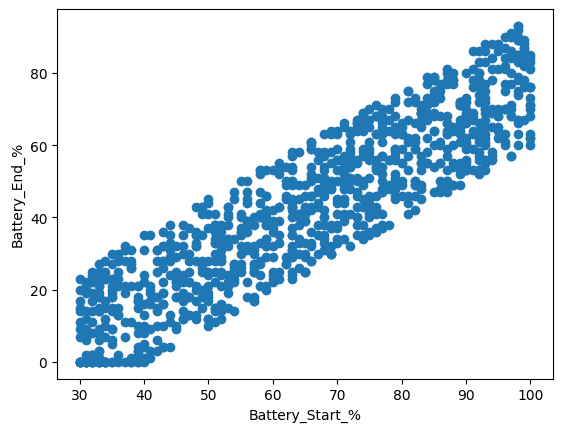

In [8]:
plt.scatter(df["Battery_Start_%"], df["Battery_End_%"])
plt.xlabel("Battery_Start_%")
plt.ylabel("Battery_End_%")
plt.show()

<Axes: xlabel='Battery_Start_%', ylabel='Battery_End_%'>

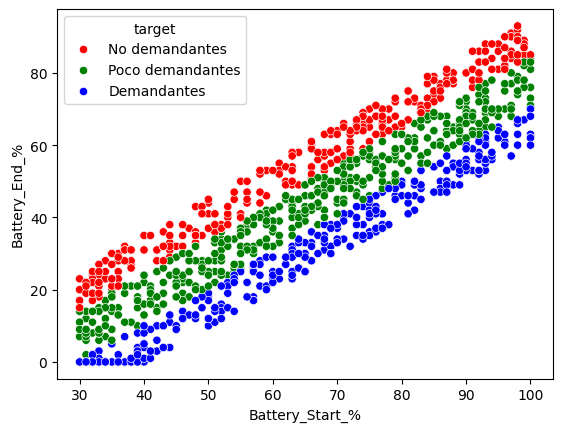

In [9]:
sns.scatterplot(data=df,
                x = df["Battery_Start_%"],
                y = df["Battery_End_%"],
                hue = df["target"],
                palette = ["r", "g", "b"])

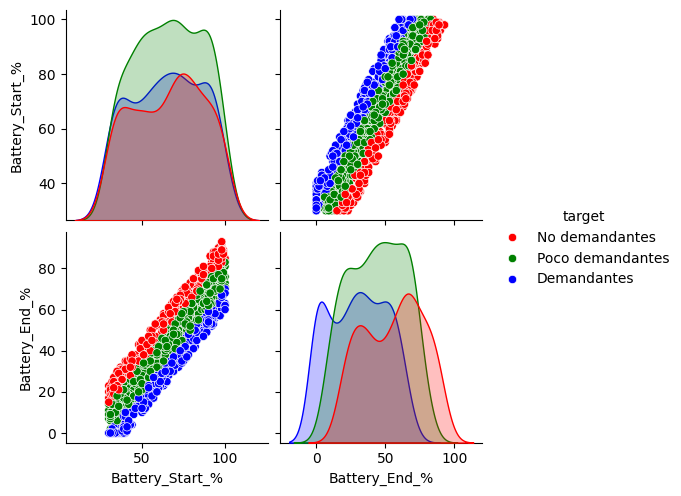

In [10]:
sns.pairplot(
    df[["Battery_Start_%",
        "Battery_End_%",
        "target"]],
       hue = "target", palette = ["r", "g", "b"]
)

### Selección de variables

Aquí se definen las variables predictoras (`X`) y la variable objetivo (`y`):


In [11]:
X = df.drop(['target', 'Battery_Drop_%'], axis=1)

# Variable a predecir
y = df[["target"]]

In [12]:
X.shape

(1000, 6)

In [13]:
y.shape

(1000, 1)

In [14]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder

### Preprocesamiento de datos: Codificación y Escalado

Esta sección prepara los datos para el modelado:

1.  **Separación de columnas:** Se identifican las columnas categóricas (tipo `object`) y numéricas.
2.  **Codificación One-Hot:** Las columnas categóricas (`Game_Name`, `Device_Type`) se transforman en representaciones numéricas binarias (One-Hot Encoding) usando `OneHotEncoder`. Esto es necesario porque los modelos de aprendizaje automático no pueden trabajar directamente con datos de texto.
3.  **Concatenación:** Las columnas numéricas originales y las columnas categóricas codificadas se combinan en un nuevo DataFrame `X_processed`.
4.  **Escalado Estándar:** Todas las características en `X_processed` se escalan utilizando `StandardScaler`. Esto transforma los datos para que tengan una media de 0 y una desviación estándar de 1, lo cual es crucial para muchos algoritmos de Machine Learning (como la Regresión Logística) ya que ayuda a que converjan más rápido y a que el modelo no se vea sesgado por características con escalas más grandes.

Se imprimen las medias y desviaciones estándar antes y después del escalado para demostrar la efectividad del `StandardScaler`.

In [15]:
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=np.number).columns

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_encoded_categorical = encoder.fit_transform(X[categorical_cols])

encoded_feature_names = encoder.get_feature_names_out(categorical_cols)
X_encoded_categorical_df = pd.DataFrame(X_encoded_categorical, columns=encoded_feature_names, index=X.index)

X_processed = pd.concat([X[numerical_cols], X_encoded_categorical_df], axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_processed)
X_scaled

array([[-0.17114254,  0.65058769, -0.60893024, ..., -0.51247074,
        -1.01816496,  1.01816496],
       [-1.56959118, -1.23380823, -0.12302995, ..., -0.51247074,
         0.98215912, -0.98215912],
       [ 1.36518132,  1.59278566,  0.70300054, ..., -0.51247074,
        -1.01816496,  1.01816496],
       ...,
       [-0.50598235, -0.76270925,  1.1403108 , ..., -0.51247074,
        -1.01816496,  1.01816496],
       [-0.26962484,  0.65058769, -0.31739007, ..., -0.51247074,
        -1.01816496,  1.01816496],
       [ 1.28639548, -0.76270925, -1.67791087, ..., -0.51247074,
         0.98215912, -0.98215912]])

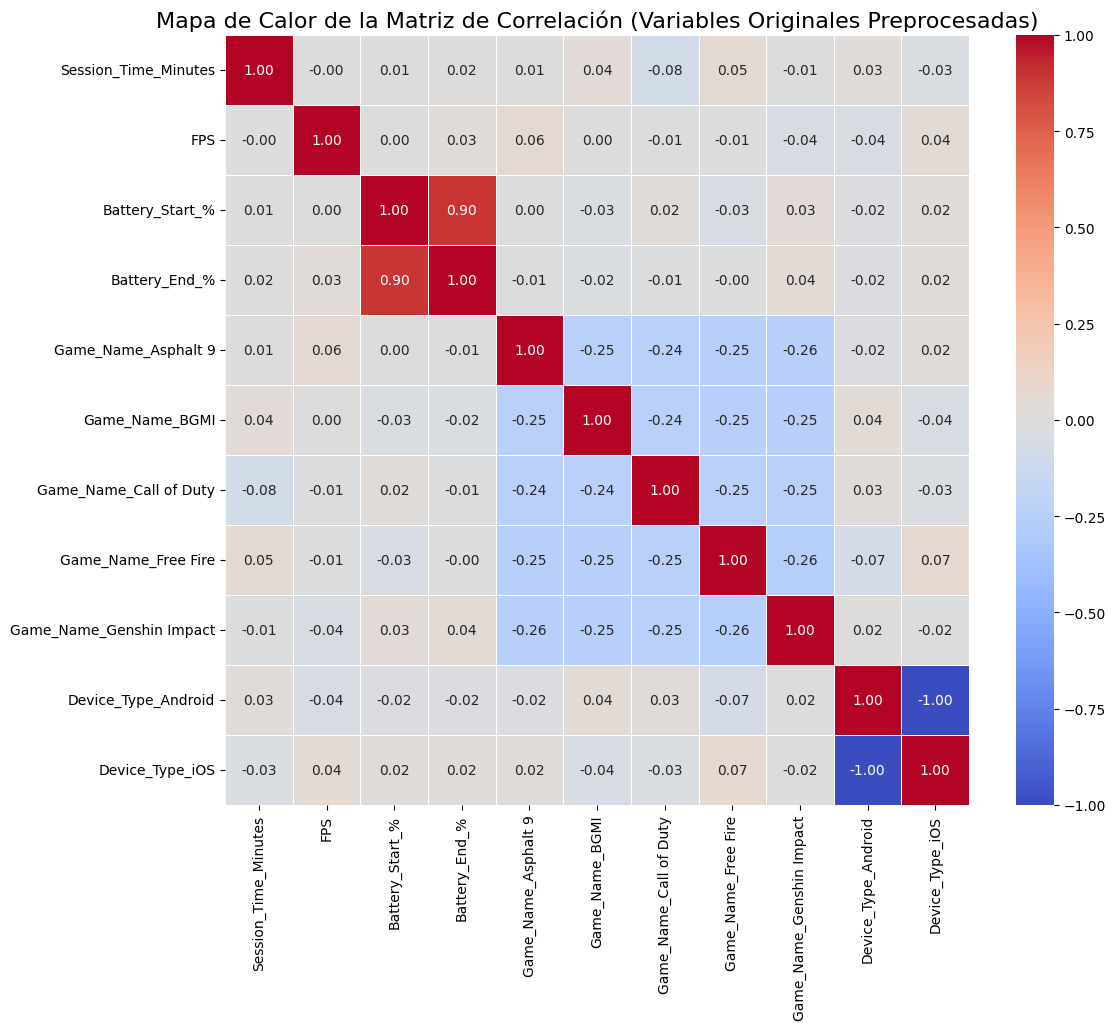

In [16]:
correlation_matrix_original = X_processed.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_original,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=.5)

plt.title('Mapa de Calor de la Matriz de Correlación (Variables Originales Preprocesadas)', fontsize=16)
plt.show()

In [17]:
print(f"Media de datos originales:{np.mean(X_processed.values):.2f}")
print(f"Media de datos escalados:{np.mean(X_scaled):.2f}")
print(f"Desviación estandar de datos originales:{np.std(X_processed.values):.2f}")
print(f"Desviación estandar de datos escalados:{np.std(X_scaled):.2f}")

Media de datos originales:24.95
Media de datos escalados:0.00
Desviación estandar de datos originales:40.00
Desviación estandar de datos escalados:1.00


<Axes: title={'center': 'Datos escalados'}, ylabel='Density'>

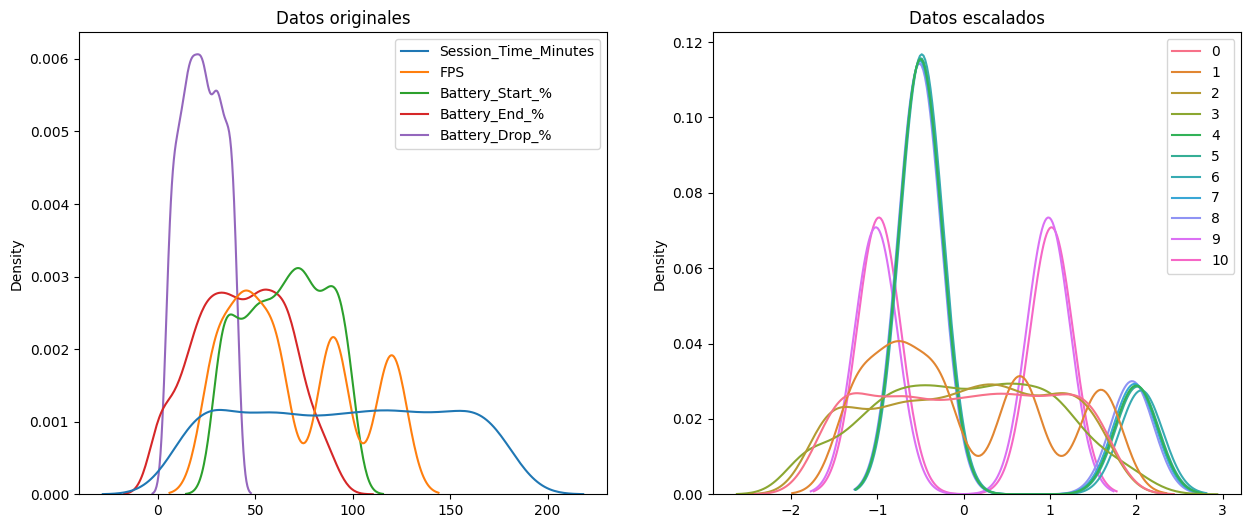

In [18]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(15, 6))
ax1.set_title("Datos originales")
sns.kdeplot(df.iloc[:, :-1], ax = ax1)
ax2.set_title("Datos escalados")
sns.kdeplot(X_scaled, ax = ax2)

### DataFrame escalado



In [19]:
df_scaled = pd.DataFrame(data = X_scaled, columns = X_processed.columns)
df_scaled

,Session_Time_Minutes,FPS,Battery_Start_%,Battery_End_%,Game_Name_Asphalt 9,Game_Name_BGMI,Game_Name_Call of Duty,Game_Name_Free Fire,Game_Name_Genshin Impact,Device_Type_Android,Device_Type_iOS
0,-0.171143,0.650588,-0.608930,-0.128654,-0.5,-0.496873,-0.485895,1.981441,-0.512471,-1.018165,1.018165
1,-1.569591,-1.233808,-0.123030,0.002314,2.0,-0.496873,-0.485895,-0.504683,-0.512471,0.982159,-0.982159
2,1.365181,1.592786,0.703001,0.307905,-0.5,-0.496873,-0.485895,1.981441,-0.512471,-1.018165,1.018165
3,-1.569591,-0.762709,-0.074440,-0.084998,-0.5,-0.496873,2.058058,-0.504683,-0.512471,0.982159,-0.982159
4,1.562146,-1.233808,0.460050,0.569841,-0.5,2.012587,-0.485895,-0.504683,-0.512471,-1.018165,1.018165
...,...,...,...,...,...,...,...,...,...,...,...
995,-1.668073,-1.233808,1.188901,0.831777,2.0,-0.496873,-0.485895,-0.504683,-0.512471,-1.018165,1.018165
996,0.951556,0.650588,0.654411,0.395217,-0.5,-0.496873,2.058058,-0.504683,-0.512471,0.982159,-0.982159
997,-0.505982,-0.762709,1.140311,0.919089,-0.5,2.012587,-0.485895,-0.504683,-0.512471,-1.018165,1.018165
998,-0.269625,0.650588,-0.317390,-0.172310,-0.5,-0.496873,-0.485895,1.981441,-0.512471,-1.018165,1.018165


In [20]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, train_size =0.66, random_state = 42)

### División del conjunto de datos (Entrenamiento y Validación)

* El 66% de los datos se utiliza para entrenar el modelos


In [21]:
print("x de entrenamiento", X_train.shape)
print("x de validación", X_val.shape)
print("y de entrenamiento", y_train.shape)
print("y de validación", y_val.shape)

x de entrenamiento (660, 11)
x de validación (340, 11)
y de entrenamiento (660, 1)
y de validación (340, 1)


### 3.- Modelado: Entrenamiento y Evaluación

In [22]:
from sklearn.ensemble import RandomForestClassifier

# Inicializar y entrenar el modelo RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train.values.ravel())

print("Entrenamiento del modelo RandomForestClassifier terminado")

Entrenamiento del modelo RandomForestClassifier terminado


#### Evaluación del Modelo



In [23]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_rf = rf_model.predict(X_val)

accuracy_rf = accuracy_score(y_val, y_pred_rf)
print(f"Precisión (RandomForest): {accuracy_rf:.4f}")

print("\nReporte de clasificación (RandomForest):")
print(classification_report(y_val, y_pred_rf))

print("\nConfusion Matrix (RandomForest):")
print(confusion_matrix(y_val, y_pred_rf))

Precisión (RandomForest): 0.7147

Reporte de clasificación (RandomForest):
                  precision    recall  f1-score   support

     Demandantes       0.88      0.62      0.73       110
  No demandantes       0.82      0.67      0.74        97
Poco demandantes       0.60      0.83      0.69       133

        accuracy                           0.71       340
       macro avg       0.77      0.71      0.72       340
    weighted avg       0.75      0.71      0.72       340


Confusion Matrix (RandomForest):
[[ 68   0  42]
 [  0  65  32]
 [  9  14 110]]


### 5.- Análisis y Selección de Características Importantes

Los modelos basados en árboles, como `RandomForestClassifier`, pueden proporcionar una estimación de la importancia de cada característica. Esto nos permite identificar qué variables contribuyen más a las decisiones del modelo. Al seleccionar solo las características más importantes, podemos:

*   **Mejorar la Precisión**: Eliminar el ruido de características irrelevantes o redundantes puede llevar a un modelo más robusto.
*   **Reducir el Sobreajuste**: Menos características significa un modelo más simple, con menos posibilidades de sobreajustarse a los datos de entrenamiento.
*   **Acelerar el Entrenamiento**: Menos características implican un entrenamiento más rápido.
*   **Mejorar la Interpretabilidad**: Entender qué características son cruciales ayuda a comprender mejor el problema y el comportamiento del modelo.

In [24]:
# Obtener las importancias de las características del mejor modelo Random Forest
# Si 'best_rf_model' no se ha ejecutado aún (por ejemplo, si el ajuste de hiperparámetros no terminó)
# puedes usar 'rf_model' del paso 3 si no se hizo tuning.

# Asegurémonos de tener un modelo entrenado para obtener las importancias
# Si usaste GridSearchCV, 'best_rf_model' será el modelo optimizado.
# Si no, 'rf_model' es el modelo inicial.

# Verificar si best_rf_model existe, si no, usar rf_model
if 'best_rf_model' in locals():
    model_for_importance = best_rf_model
    # Cuando se usa best_rf_model, las características son las top_features seleccionadas
    feature_names_for_df = top_features
elif 'rf_model' in locals(): # Fallback a rf_model inicial si best_rf_model no está disponible
    model_for_importance = rf_model
    # Cuando se usa rf_model, las características son todas las procesadas originalmente
    feature_names_for_df = X_processed.columns
else:
    raise RuntimeError("No hay ningún modelo (best_rf_model o rf_model) disponible para calcular la importancia de las características.")

importances = model_for_importance.feature_importances_

# Crear un DataFrame para las importancias de las características
# Usar feature_names_for_df que se definió condicionalmente
feature_importances = pd.DataFrame({'feature': feature_names_for_df, 'importance': importances})

# Ordenar las características por importancia de forma descendente
feature_importances = feature_importances.sort_values(by='importance', ascending=False)

print("Importancia de las características:")
display(feature_importances)

Importancia de las características:


,feature,importance
3,Battery_End_%,0.383844
2,Battery_Start_%,0.259175
0,Session_Time_Minutes,0.184153
1,FPS,0.070873
6,Game_Name_Call of Duty,0.016050
4,Game_Name_Asphalt 9,0.015822
7,Game_Name_Free Fire,0.015759
8,Game_Name_Genshin Impact,0.015371
5,Game_Name_BGMI,0.015008
10,Device_Type_iOS,0.012185


### Visualización de la Importancia de las Características



/tmp/ipykernel_9737/1343019968.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importances, palette='viridis')


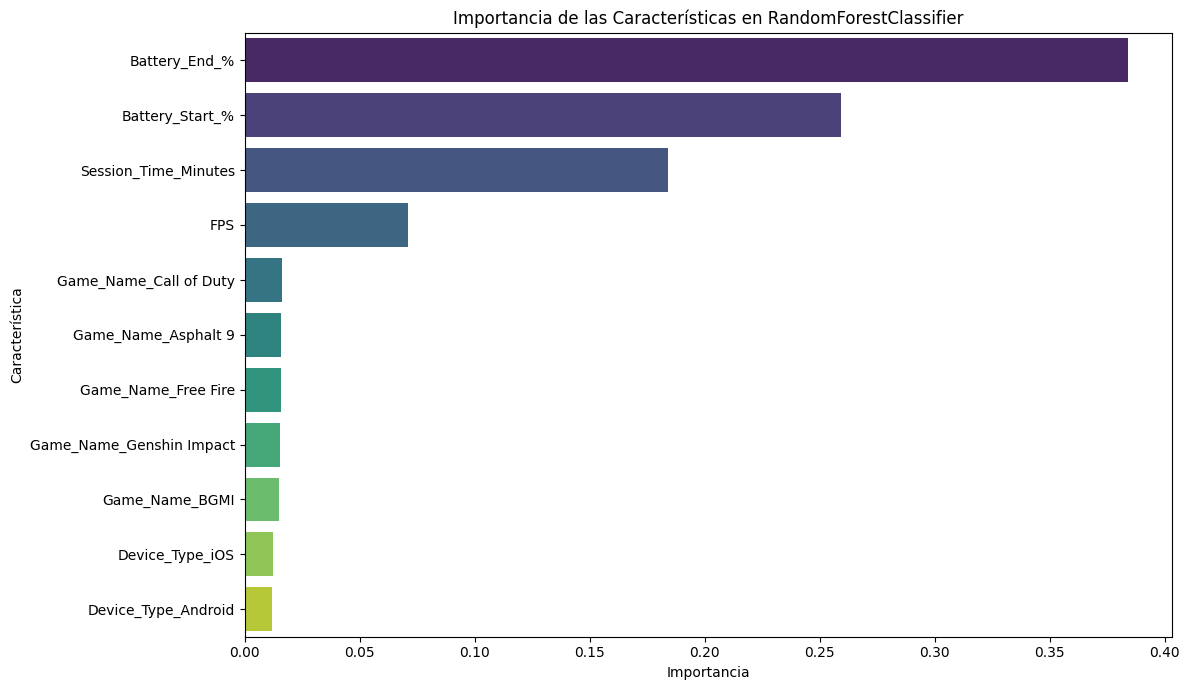

In [25]:
plt.figure(figsize=(12, 7))
sns.barplot(x='importance', y='feature', data=feature_importances, palette='viridis')
plt.title('Importancia de las Características en RandomForestClassifier')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()


### Selección de Características y Reentrenamiento del Modelo



In [26]:
# Definir un umbral o seleccionar un número top de características
# Por ejemplo, seleccionemos las 6 características más importantes
num_top_features = 6
top_features = feature_importances.head(num_top_features)['feature'].tolist()
print(f"Las {num_top_features} características más importantes son: {top_features}")

# Crear nuevos conjuntos de datos de entrenamiento y validación con solo estas características
X_train_selected = pd.DataFrame(X_train, columns=feature_names)[top_features].values
X_val_selected = pd.DataFrame(X_val, columns=feature_names)[top_features].values

print("\nDimensiones del conjunto de entrenamiento con características seleccionadas:", X_train_selected.shape)
print("Dimensiones del conjunto de validación con características seleccionadas:", X_val_selected.shape)

# Reentrenar el modelo con las características seleccionadas
# Usaremos el modelo 'best_rf_model' si existe, o 'rf_model' como base.

# Inicializar y entrenar un nuevo modelo RandomForestClassifier con las características seleccionadas
# Si 'best_rf_model' fue ajustado, podemos usar sus mejores parámetros para el nuevo modelo
if 'best_rf_model' in locals():
    params = best_rf_model.get_params()
    # Eliminar random_state del diccionario de parámetros para evitar la duplicación
    params.pop('random_state', None)
    rf_model_selected = RandomForestClassifier(**params, random_state=42)
else:
    rf_model_selected = RandomForestClassifier(random_state=42)

rf_model_selected.fit(X_train_selected, y_train.values.ravel())

print("\nModelo RandomForestClassifier reentrenado con características seleccionadas.")

# Evaluar el modelo con las características seleccionadas
y_pred_rf_selected = rf_model_selected.predict(X_val_selected)

accuracy_rf_selected = accuracy_score(y_val, y_pred_rf_selected)
print(f"\nPrecisión (RandomForest con características seleccionadas): {accuracy_rf_selected:.4f}")

print("\nReporte de clasificación (RandomForest con características seleccionadas):")
print(classification_report(y_val, y_pred_rf_selected))

print("\nConfusion Matrix (RandomForest con características seleccionadas):")
print(confusion_matrix(y_val, y_pred_rf_selected))


Las 6 características más importantes son: ['Battery_End_%', 'Battery_Start_%', 'Session_Time_Minutes', 'FPS', 'Game_Name_Call of Duty', 'Game_Name_Asphalt 9']


NameError: name 'feature_names' is not defined